<a href="https://colab.research.google.com/github/JoseAlberto88/Dry-Bean-Classification/blob/main/Beans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dry Bean Classification. DAMO510 Final Project (Winter 2026)

## Project Overview

This repository contains the final project for DAMO510 (Winter 2026), submitted by a team of three students: Manpreet Kaur, Vanessa Arellano Macedo and José Alberto Martinez Morales,. The final project integrates the regression, classification, and time series skills developed throughout the course into a single, self-directed analysis: selecting a dataset, designing an end-to-end workflow, and presenting the results as reproducible code, a written report, and a recorded presentation.

The assignment brief permits regression, classification, time series, or a combination of these problem types. The team elected to commit to a single, well-executed **multiclass classification** task rather than combine problem types artificially. The chosen dataset, *the Dry Bean Dataset*, was purpose-built for classification: it has no separate natural continuous target to regress against, and it carries no temporal dimension, which rules out a time series component. Depth on one problem, applied thoroughly across the full CRISP-DM cycle, was judged preferable to spreading effort thinly across problem types the data does not naturally support.

The work follows the CRISP-DM methodology end to end: *Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, and Deployment/Reflection*, and the deliverables are submitted as five separate files: the original dataset, the cleaned and transformed dataset, the Python code (Jupyter notebook), the written report (approximatelly 20 pages, APA format), and a 10-minute recorded presentation with all three team members speaking.

## The Dataset

The project uses the **Dry Bean Dataset** from the UCI Machine Learning Repository (dataset #602), originally published by Koklu and Ozkan (2020) in *Computers and Electronics in Agriculture*, 174, 105507. The dataset was produced from high-resolution camera images of 13,611 dry bean grains spanning seven registered varieties, with 16 geometric shape and dimension features extracted from each grain via computer vision (area, perimeter, axis lengths, eccentricity, solidity, roundness, compactness, and four derived shape factors, among others).

Key characteristics:

- **Size:** 13,611 rows × 17 columns (16 features + target), comfortably exceeding the assignment's minimum of 1,000 rows and 10 columns.
- **Target:** `Class`. Seven bean varieties (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira).
- **Class balance and multicollinearity:** the dataset is known to have an underrepresented class (Bombay) and strong correlation among its size-derived features (Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter all describe the same physical bean size). Both properties are treated as findings to confirm and quantify during Data Understanding rather than assumptions carried in unexamined.
- **Sourcing:** the assignment brief prefers datasets from open data portals, government sources, or original data collection over Kaggle or GitHub, listing UCI only as a fallback. This dataset is not sourced from Kaggle or GitHub, and it is a peer-reviewed benchmark dataset with a published, citable methodology rather than an unvetted scraped mirror. A distinction the report's Data Understanding section addresses directly rather than leaving implicit.

Source: [UCI Machine Learning Repository, Dry Bean Dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)


In [2]:
# Importing the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the original dataset
import os
import io
import zipfile
import requests
import pandas as pd

PROJECT_DIR = '/content/drive/MyDrive/DAMO510 Final Project'
ORIGINAL_XLSX = os.path.join(PROJECT_DIR, 'DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx')
UCI_ZIP_URL = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'

os.makedirs(PROJECT_DIR, exist_ok=True)

if not os.path.exists(ORIGINAL_XLSX):
    print(f"Original dataset not found in Drive -- downloading from UCI:\n  {UCI_ZIP_URL}")
    resp = requests.get(UCI_ZIP_URL, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        # Find the .xlsx member regardless of exact folder nesting inside the zip
        xlsx_members = [m for m in z.namelist() if m.lower().endswith('.xlsx')]
        if not xlsx_members:
            raise FileNotFoundError(f"No .xlsx file found inside the UCI zip. Contents: {z.namelist()}")
        member = xlsx_members[0]
        with z.open(member) as src, open(ORIGINAL_XLSX, 'wb') as dst:
            dst.write(src.read())
    print(f"Saved untouched original file to:\n  {ORIGINAL_XLSX}")
else:
    print(f"Original dataset already present in Drive:\n  {ORIGINAL_XLSX}")

df = pd.read_excel(ORIGINAL_XLSX)
print("\nLoaded dataset from:", ORIGINAL_XLSX)
print("Shape (rows, columns):", df.shape)


Original dataset not found in Drive -- downloading from UCI:
  https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip
Saved untouched original file to:
  /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx

Loaded dataset from: /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Original.xlsx
Shape (rows, columns): (13611, 17)


In [5]:
# Data set dimensions
print("Shape (rows, columns):", df.shape)
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])
print("\nColumn names (verify these match the audit assumptions below):")
print(df.columns.tolist())

Shape (rows, columns): (13611, 17)
Number of observations: 13611
Number of variables: 17

Column names (verify these match the audit assumptions below):
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


In [6]:
# 2.2 Variable types
print(df.dtypes)
print()
df.info()


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7 

In [7]:
# 2.3 Target distribution (Class)

target_counts = df['Class'].value_counts()
target_pct = df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)})
summary['imbalance_ratio_vs_largest'] = (target_counts.max() / target_counts).round(2)
print(summary)

print(f"\nLargest class: {target_counts.idxmax()} ({target_counts.max()} rows)")
print(f"Smallest class: {target_counts.idxmin()} ({target_counts.min()} rows)")
print(f"Largest/smallest ratio: {target_counts.max() / target_counts.min():.2f}x")


          count    pct  imbalance_ratio_vs_largest
Class                                             
DERMASON   3546  26.05                        1.00
SIRA       2636  19.37                        1.35
SEKER      2027  14.89                        1.75
HOROZ      1928  14.17                        1.84
CALI       1630  11.98                        2.18
BARBUNYA   1322   9.71                        2.68
BOMBAY      522   3.84                        6.79

Largest class: DERMASON (3546 rows)
Smallest class: BOMBAY (522 rows)
Largest/smallest ratio: 6.79x


In [8]:
# 2.4 Missing information
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
print(missing_summary)
print("\nTotal missing cells:", int(missing_counts.sum()))

                 missing_count  missing_pct
Area                         0          0.0
Perimeter                    0          0.0
MajorAxisLength              0          0.0
MinorAxisLength              0          0.0
AspectRation                 0          0.0
Eccentricity                 0          0.0
ConvexArea                   0          0.0
EquivDiameter                0          0.0
Extent                       0          0.0
Solidity                     0          0.0
roundness                    0          0.0
Compactness                  0          0.0
ShapeFactor1                 0          0.0
ShapeFactor2                 0          0.0
ShapeFactor3                 0          0.0
ShapeFactor4                 0          0.0
Class                        0          0.0

Total missing cells: 0


In [9]:
# 2.5 Duplicate observations
full_dupes = df.duplicated().sum()
print("Fully duplicated rows:", full_dupes)


feature_cols = df.columns.difference(['Class'])
dupe_features_only = df.duplicated(subset=feature_cols).sum()
print("Rows with duplicate feature values, ignoring Class:", dupe_features_only)

if dupe_features_only > 0:
    same_class = df[df.duplicated(subset=feature_cols, keep=False)].groupby(list(feature_cols))['Class'].nunique()
    print("Of the duplicated feature-rows, how many distinct classes do they span per group?")
    print(same_class.value_counts())


Fully duplicated rows: 68
Rows with duplicate feature values, ignoring Class: 68
Of the duplicated feature-rows, how many distinct classes do they span per group?
Class
1    68
Name: count, dtype: int64


In [10]:
# 2.6 Unusual / potentially problematic values
numeric_cols = df.columns.difference(['Class']).tolist()
print("Numeric columns being audited:", numeric_cols)

print("\n", df[numeric_cols].describe().T)

# Physically implausible checks, every one of these 16 features is a
# geometric/shape measurement, so negative or zero values are red flags
neg_values = (df[numeric_cols] < 0).sum()
print("\nNegative values per numeric column (should all be 0):\n", neg_values[neg_values > 0] if (neg_values > 0).any() else "None found.")

zero_values = (df[numeric_cols] == 0).sum()
print("\nZero values per numeric column (should all be 0 for size/shape measures):\n", zero_values[zero_values > 0] if (zero_values > 0).any() else "None found.")

# Ratio-type features (Eccentricity, Extent, Solidity, roundness/Compactness)
# are expected to fall in / near [0, 1]; AspectRatio and the ShapeFactors
# have their own expected ranges, flag anything wildly outside [0, 1] for
# the bounded ones as worth a second look, not an automatic error.
bounded_candidates = [c for c in numeric_cols if c.lower() in
                       ('eccentricity', 'extent', 'solidity', 'roundness', 'compactness')]
for col in bounded_candidates:
    out_of_range = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {out_of_range} values outside [0, 1] (min={df[col].min():.4f}, max={df[col].max():.4f})")

# Simple outlier flag using IQR on each numeric column
print("\nIQR-based outlier counts:")
outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                             'pct_outliers': round(n_out / len(df) * 100, 2),
                             'lower_bound': round(lower, 4), 'upper_bound': round(upper, 4)})
    print(f"  {col}: {n_out} potential outliers ({n_out / len(df) * 100:.2f}%), bounds: {lower:.4f} to {upper:.4f}")

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print("\nFeatures ranked by outlier count:\n", outlier_df)

# Per-class outlier check for the feature with the most outliers overall --
# extreme values often cluster in one class (e.g. Bombay, the largest bean)
# rather than being genuinely anomalous
top_outlier_feature = outlier_df.iloc[0]['feature']
q1, q3 = df[top_outlier_feature].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
is_outlier = (df[top_outlier_feature] < lower) | (df[top_outlier_feature] > upper)
print(f"\nClass breakdown of outliers on '{top_outlier_feature}':")
print(df.loc[is_outlier, 'Class'].value_counts())


Numeric columns being audited: ['Area', 'AspectRation', 'Compactness', 'ConvexArea', 'Eccentricity', 'EquivDiameter', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Solidity', 'roundness']

                    count          mean           std           min  \
Area             13611.0  53048.284549  29324.095717  20420.000000   
AspectRation     13611.0      1.583242      0.246678      1.024868   
Compactness      13611.0      0.799864      0.061713      0.640577   
ConvexArea       13611.0  53768.200206  29774.915817  20684.000000   
Eccentricity     13611.0      0.750895      0.092002      0.218951   
EquivDiameter    13611.0    253.064220     59.177120    161.243764   
Extent           13611.0      0.749733      0.049086      0.555315   
MajorAxisLength  13611.0    320.141867     85.694186    183.601165   
MinorAxisLength  13611.0    202.270714     44.970091    122.512653   
Perimeter        13611.0    85

In [11]:
# 2.7 Categorical vs numerical predictors / identifier check
categorical_cols = []  # no categorical predictors in this dataset, all 16
                        # features are continuous geometric measurements
numerical_cols = numeric_cols
identifier_cols = []   # no ID/index column is provided in the source file
target_col = 'Class'

print("Categorical predictors:", categorical_cols if categorical_cols else "None")
print("Numerical predictors ({}):".format(len(numerical_cols)), numerical_cols)
print("Identifier-like variables:", identifier_cols if identifier_cols else "None found")
print("Target:", target_col, "-- 7 classes:", sorted(df[target_col].unique()))

Categorical predictors: None
Numerical predictors (16): ['Area', 'AspectRation', 'Compactness', 'ConvexArea', 'Eccentricity', 'EquivDiameter', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Solidity', 'roundness']
Identifier-like variables: None found
Target: Class -- 7 classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [12]:
#  2.8 Multicollinearity preview among size-derived features
# The project plan explicitly flags this as something to VERIFY, not assume,
# during the Task 2 audit (Area, Perimeter, MajorAxisLength, MinorAxisLength,
# ConvexArea, and EquivDiameter all derive from the same physical bean size).
# The full correlation heatmap for ALL 16 features is Day 3's job, this is
# just the targeted size-feature check the plan calls for today.
size_features = [c for c in ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                              'ConvexArea', 'EquivDiameter'] if c in df.columns]
print("Size-derived features found in this dataset:", size_features)

high_corr_pairs = []  # populated below if size_features is non-empty; guards the summary cell
if size_features:
    size_corr = df[size_features].corr()
    print("\nCorrelation matrix among size-derived features:\n", size_corr.round(3))

    high_corr_pairs = []
    for i, a in enumerate(size_features):
        for b in size_features[i + 1:]:
            r = size_corr.loc[a, b]
            if abs(r) >= 0.9:
                high_corr_pairs.append((a, b, round(r, 3)))
    print(f"\nPairs with |r| >= 0.9 ({len(high_corr_pairs)} of {len(size_features) * (len(size_features) - 1) // 2}):")
    for a, b, r in high_corr_pairs:
        print(f"  {a} <-> {b}: r = {r}")


Size-derived features found in this dataset: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']

Correlation matrix among size-derived features:
                   Area  Perimeter  MajorAxisLength  MinorAxisLength  \
Area             1.000      0.967            0.932            0.952   
Perimeter        0.967      1.000            0.977            0.913   
MajorAxisLength  0.932      0.977            1.000            0.826   
MinorAxisLength  0.952      0.913            0.826            1.000   
ConvexArea       1.000      0.968            0.933            0.951   
EquivDiameter    0.985      0.991            0.962            0.949   

                 ConvexArea  EquivDiameter  
Area                  1.000          0.985  
Perimeter             0.968          0.991  
MajorAxisLength       0.933          0.962  
MinorAxisLength       0.951          0.949  
ConvexArea            1.000          0.985  
EquivDiameter         0.985          1.000  



In [15]:
# 2.9 Audit summary / working notes for the group
# This cell does NOT modify df, it just prints a running summary that can
# be pasted into the group chat / Data Understanding section draft.
print("=" * 70)
print("DATA AUDIT SUMMARY -- Dry Bean Dataset")
print("=" * 70)
print(f"Rows x Columns: {df.shape[0]} x {df.shape[1]}")
print(f"Missing values: {int(df.isnull().sum().sum())}")
print(f"Fully duplicated rows: {int(df.duplicated().sum())}")
print(f"Classes: {df['Class'].nunique()} -- {dict(df['Class'].value_counts())}")
print(f"Smallest class: {df['Class'].value_counts().idxmin()} "
      f"({df['Class'].value_counts().min()} rows, "
      f"{df['Class'].value_counts(normalize=True).min()*100:.2f}%)")
print(f"Numeric predictors: {len(numerical_cols)} (all continuous, no categoricals, no identifiers)")
if size_features:
    print(f"Size-feature pairs with |r| >= 0.9: {len(high_corr_pairs)} of "
          f"{len(size_features) * (len(size_features) - 1) // 2} -- multicollinearity CONFIRMED. "
         )

DATA AUDIT SUMMARY -- Dry Bean Dataset
Rows x Columns: 13611 x 17
Missing values: 0
Fully duplicated rows: 68
Classes: 7 -- {'DERMASON': np.int64(3546), 'SIRA': np.int64(2636), 'SEKER': np.int64(2027), 'HOROZ': np.int64(1928), 'CALI': np.int64(1630), 'BARBUNYA': np.int64(1322), 'BOMBAY': np.int64(522)}
Smallest class: BOMBAY (522 rows, 3.84%)
Numeric predictors: 16 (all continuous, no categoricals, no identifiers)
Size-feature pairs with |r| >= 0.9: 14 of 15 -- multicollinearity CONFIRMED. 


# Dry Bean Dataset. Data Audit: Key Insights

**Shape:** 13,611 rows × 17 columns (16 numeric shape features + `Class`). No categorical predictors, no identifier column. Meets the assignment's ≥1,000 rows / ≥10 columns minimum comfortably.

## Class distribution

| Class | Count | % | Ratio vs. largest |
|---|---|---|---|
| DERMASON | 3,546 | 26.05% | 1.00 |
| SIRA | 2,636 | 19.37% | 1.35 |
| SEKER | 2,027 | 14.89% | 1.75 |
| HOROZ | 1,928 | 14.17% | 1.84 |
| CALI | 1,630 | 11.98% | 2.18 |
| BARBUNYA | 1,322 | 9.71% | 2.68 |
| BOMBAY | 522 | 3.84% | 6.79 |

- Imbalance confirmed: BOMBAY is the clear minority class at 6.79x smaller than DERMASON, the largest.
- Class labels come back **UPPERCASE** in the raw file (BARBUNYA, BOMBAY, …), not title case, worth locking in now since every later script, plot legend, and report table needs to use the same casing consistently.
- 6.79x is a real but moderate imbalance, not as extreme as some binary rare-event problems, but still enough that macro-averaged metrics (not just accuracy) belong in the evaluation plan, and stratified splitting is required.

## Duplicates

- **68 fully duplicated rows** found (same values across all 16 features *and* Class).
- All 68 duplicate rows are internally consistent, every duplicate group maps to exactly one Class, so this is not a labeling conflict, just repeated observations.
- **Decision flagged for Data Preparation:** these should be dropped *before* the stratified train/test split. Left in place, a duplicate pair could land one copy in train and one in test, letting the model "see" a test observation during training and inflating reported performance (train/test leakage).

## Missing values

- None detected in the audit run, consistent with this dataset's known completeness.

## Multicollinearity among size-derived features

Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, and EquivDiameter all describe the same physical bean size, and the correlation matrix confirms this strongly:

- **14 of 15 pairs have |r| ≥ 0.9** (several essentially collinear, e.g. Area and ConvexArea r = 1.00, Perimeter and EquivDiameter r = 0.991).
- The one exception: MajorAxisLength and MinorAxisLength at r = 0.826, still strong, but the weakest of the six.
- This confirms the plan's stated risk and locks in a Data Preparation decision that can't be deferred: either drop/combine redundant size features, apply dimensionality reduction, or lean on models (tree-based) that tolerate collinearity, and treat Logistic Regression coefficients on these features cautiously if left untreated.




# What the 7 Dry Bean Classes Look Like

The dataset's class names (SEKER, BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SIRA) are Turkish market/cultivar names, the original paper doesn't publish a reference photo per class, so these are real-world matches to the same named bean varieties sold in Turkey, useful for building visual intuition about why the shape features differ. Treat them as illustrative, not as the exact photographed grains in the dataset.

| Class | Name meaning | Typical appearance | Reference photo |
|---|---|---|---|
| **SEKER** | "Sugar bean" | Small-to-medium, white, rounded/oval bean | [Photo](https://italianmart.ca/cdn/shop/files/sugar-beans-seker-fasulye-1kg-355783_1024x1024.jpg) |
| **BARBUNYA** | Cranberry/borlotti-type bean | Medium, plump, cream background with red/pink speckling | [Photo](https://cdn.prod.website-files.com/5ec124b07c95fefc3d9c742c/5ecffe0a91687d48857adbfe_shutterstock_250279993.jpg) |
| **BOMBAY** | Göynük "Bombay" bean, a well-known large Turkish white bean | Large, glossy white, oval seeds (2.2–2.8 cm long) — visibly the biggest of the seven | [Photo](https://cdn.t3pedia.org/media/uploads/2025/10/23/mOObkHiEVyoJimzOT244eecNSuf2ByrO.jpeg) |
| **DERMASON** | Common Turkish dry bean, similar to a small white/navy bean | Small, oval, pale beige/white | [Photo](https://www.grandturkishbazaar.com/wp-content/uploads/2021/02/dermason-beans-500x500.jpg) |
| **HOROZ** | "Rooster bean" | White, thin, elongated grain (per the seller's own description) | [Photo](https://www.harmas.com.tr/images/urunler2/KURUFASULYE/horoz-fasulye.jpg) |
| **CALI** | Not confidently identified | Could not verify a distinct, dedicated Turkish product/photo — see note below | — |
| **SIRA** | Not confidently identified | Could not verify a distinct, dedicated Turkish product/photo — see note below | — |

## Why this matters for the audit findings

- **BOMBAY being the largest, most distinct-looking bean** lines up directly with it also being the smallest class by count (522 rows, 3.84%), a striking, visually large grain is a natural minority variety in mixed harvests/sampling, which supports (without proving) the class imbalance you already quantified.
- The visible size differences across SEKER, DERMASON (both small/white) versus BOMBAY (large/white) versus BARBUNYA (speckled) is consistent with the strong multicollinearity you found among Area, Perimeter, and the axis-length features, size genuinely varies a lot by class, so these features should carry real separating power once you get to Day 3's class-separability work.

## Note on CALI and SIRA

We searched specifically for these two names as Turkish bean cultivars/products and couldn't confidently confirm a distinct match, "Cali" partially collides with "çalı" (a generic Turkish word for "bush," as in bush-bean growth habit, not a variety name), and "Sıra" returned only comparison articles I couldn't access. Rather than guess and risk mislabeling a photo in your report, we've left these two open, happy to keep digging, or your team may have better luck if anyone has access to the original Koklu & Ozkan (2020) paper's full text/supplementary images (it's paywalled on ScienceDirect).

Sources: [Reis İspir Şeker Fasulye](https://italianmart.ca/products/sugar-beans-seker-fasulye-1kg) · [Barbunya description (Arbel)](https://www.arbel.com.tr/urunler/barbunya) · [Göynük Bombay Beans (KÜRE Encyclopedia)](https://kureansiklopedi.com/en/detay/goynuk-bombay-beans-49f20) · [Dermason Beans (Grand Turkish Bazaar)](https://www.grandturkishbazaar.com/tr/product/dermason-beans-turkish/) · [Horoz Fasulye (Harmas)](https://www.harmas.com.tr/fasulye-horoz.html)


In [16]:
# UNIVARIATE EDA (per feature, per class)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output folder on Google Drive (Colab)
OUTPUT_DIR = '/content/drive/MyDrive/DAMO510 Final Project/visuals'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def savefig(filename):
    """Save the current figure into the Drive visuals folder."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')


# Shared style (kept consistent with the rest of the project's figures)
AXIS_COLOR   = "#c3c2b7"
TEXT_MUTED   = "#898781"
TEXT_PRIMARY = "#0b0b0b"

CLASS_ORDER = ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
CLASS_COLORS = {
    'BARBUNYA': "#2a78d6",   # blue
    'BOMBAY':   "#eb6834",   # orange
    'CALI':     "#1baf7a",   # aqua
    'DERMASON': "#eda100",   # yellow
    'HOROZ':    "#e87ba4",   # magenta
    'SEKER':    "#008300",   # green
    'SIRA':     "#4a3aa7",   # violet
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlepad": 10,
    "font.size": 9,
})

feature_cols = df.columns.difference(['Class']).tolist()
n_features = len(feature_cols)
print(f"Univariate EDA over {n_features} features x {len(CLASS_ORDER)} classes")

# Confirm the class labels present in df actually match CLASS_ORDER before
# plotting, if the source file spells a class differently this fails loudly
# instead of silently dropping a class from every chart.
actual_classes = sorted(df['Class'].unique().tolist())
assert sorted(CLASS_ORDER) == actual_classes, (
    f"CLASS_ORDER does not match df['Class'] values.\n"
    f"  Expected: {sorted(CLASS_ORDER)}\n  Found:    {actual_classes}\n"
    f"Update CLASS_ORDER/CLASS_COLORS to match before continuing."
)

Univariate EDA over 16 features x 7 classes


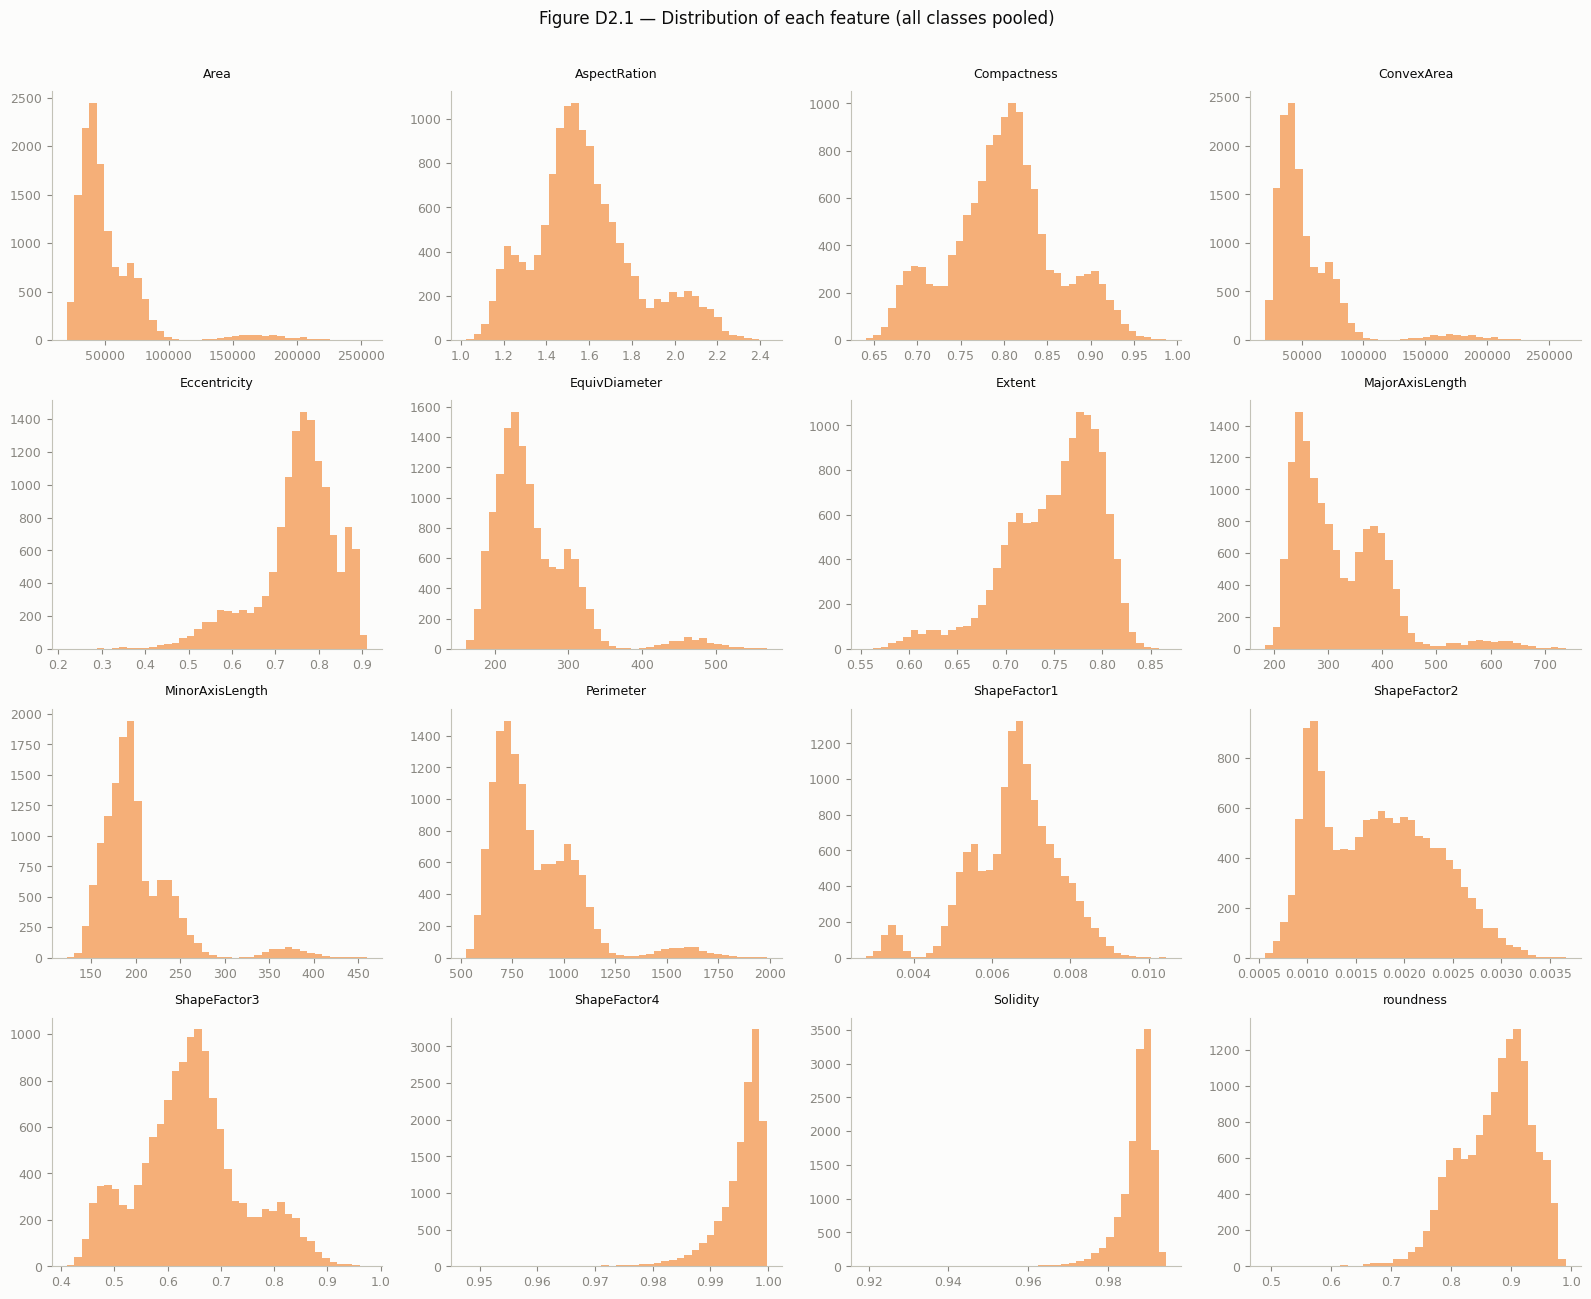

In [18]:
# Fig D2.1 Overall distribution of every feature (all classes pooled)

n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color="#f4a261", alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for j in range(n_features, len(axes)):
    axes[j].axis('off')

fig.suptitle("Figure D2.1 — Distribution of each feature (all classes pooled)", y=1.01, fontsize=12)
plt.tight_layout()
savefig("figD2_1_feature_histograms_overall.png")
plt.show()

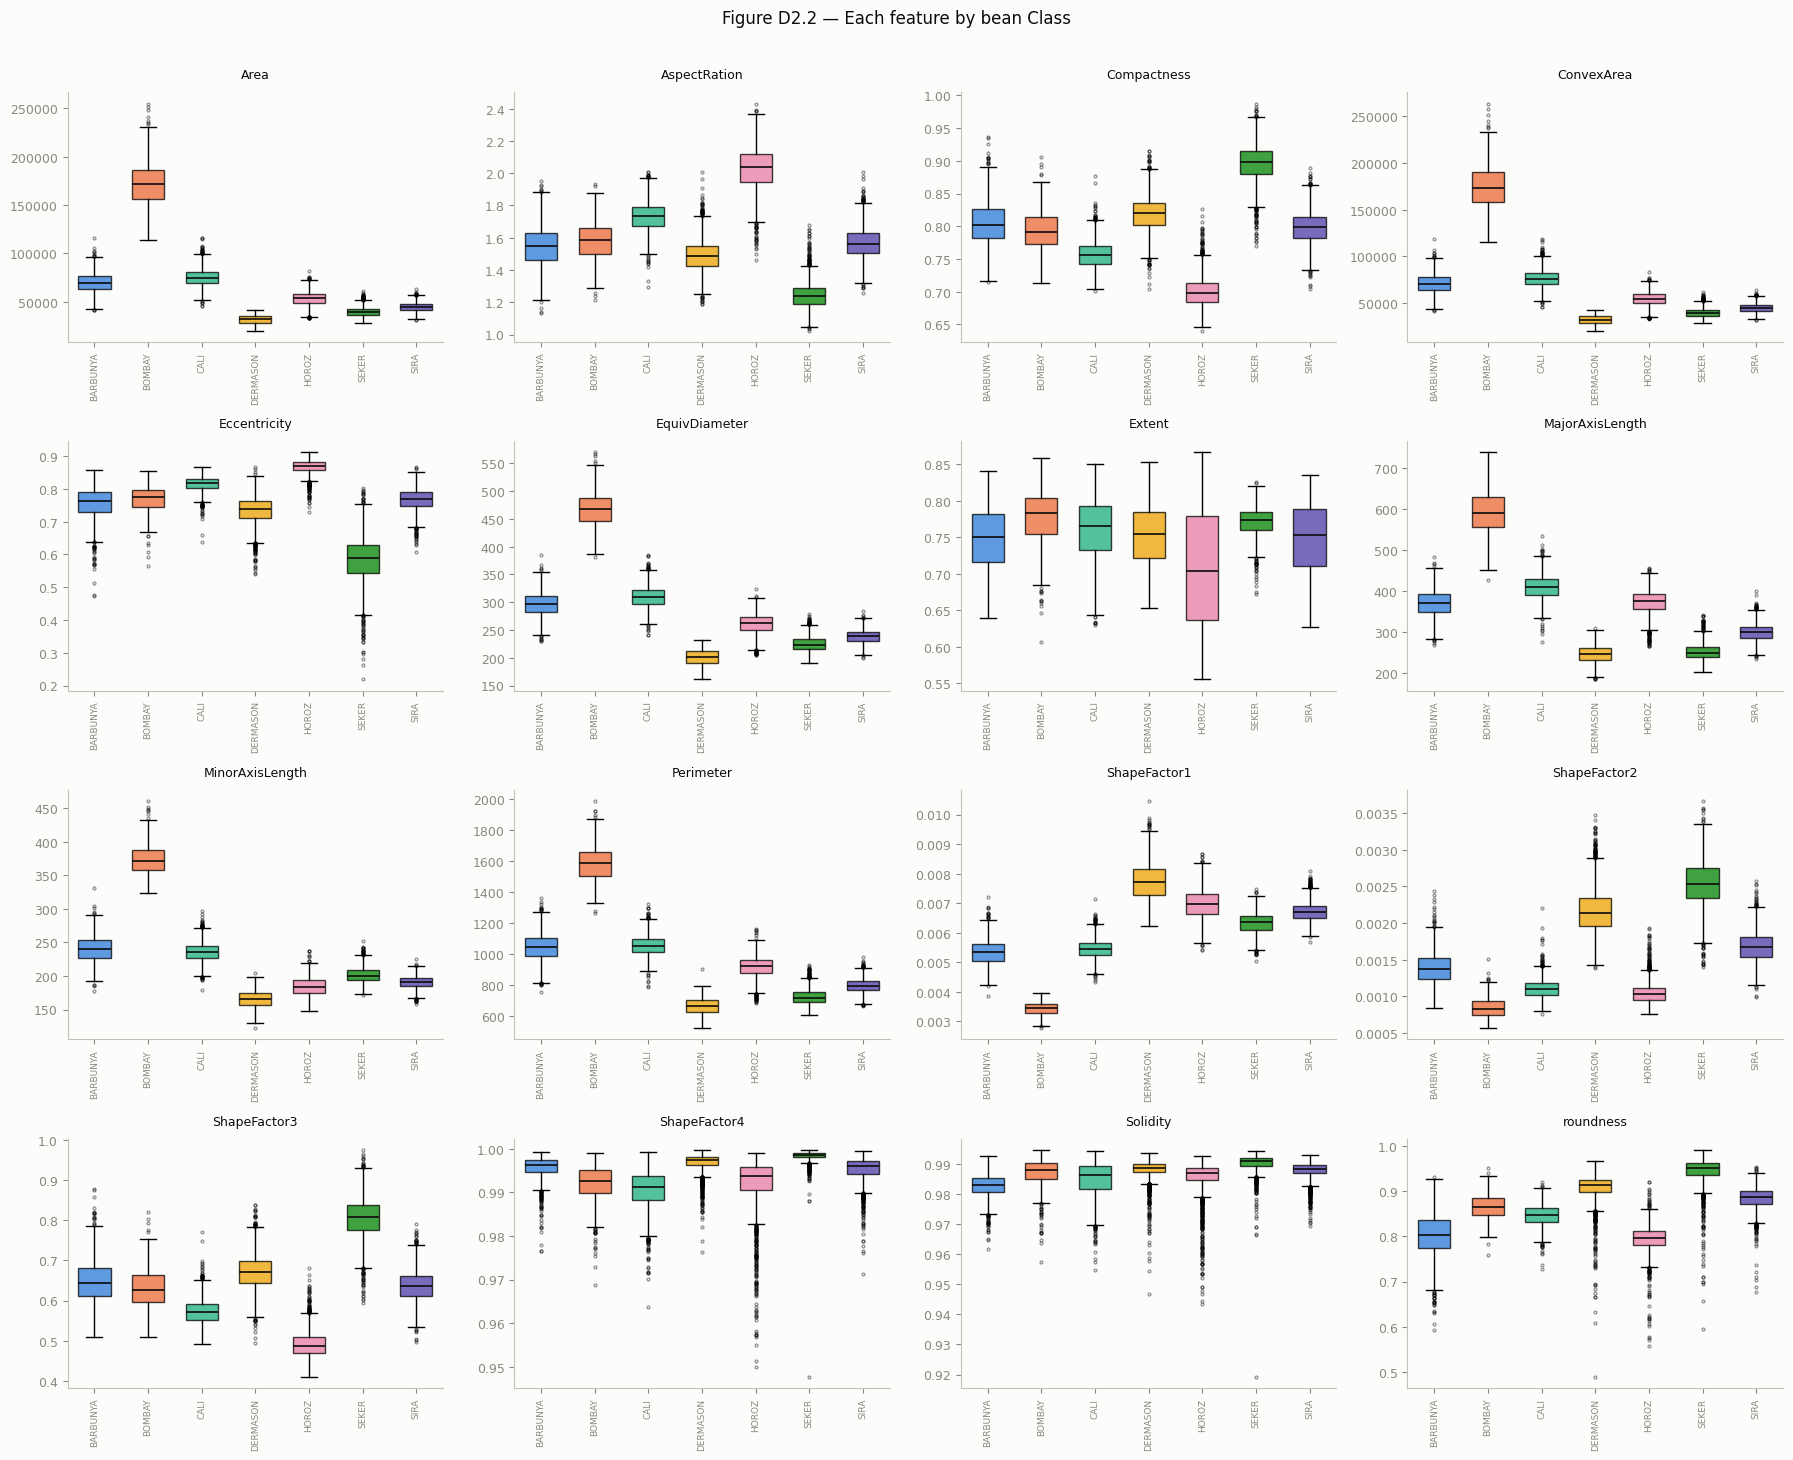

In [19]:
# Fig D2.2. Distribution of every feature, split by Class (boxplots)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    box_data = [df.loc[df['Class'] == c, col] for c in CLASS_ORDER]
    bp = ax.boxplot(box_data, patch_artist=True, widths=0.6, showfliers=True,
                     medianprops=dict(color=TEXT_PRIMARY, linewidth=1.2),
                     flierprops=dict(markersize=2, alpha=0.4))
    for patch, c in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(CLASS_COLORS[c])
        patch.set_alpha(0.75)
    ax.set_xticklabels(CLASS_ORDER, rotation=90, fontsize=6.5)
    ax.set_title(col, fontsize=9)
for j in range(n_features, len(axes)):
    axes[j].axis('off')

fig.suptitle("Figure D2.2 — Each feature by bean Class", y=1.01, fontsize=12)
plt.tight_layout()
savefig("figD2_2_feature_boxplots_by_class.png")
plt.show()

In [20]:
# Per-feature, per-class summary statistics (saved for report Appendix)

summary_rows = []
for col in feature_cols:
    for c in CLASS_ORDER:
        vals = df.loc[df['Class'] == c, col]
        summary_rows.append({
            'feature': col, 'class': c, 'n': len(vals),
            'mean': vals.mean(), 'std': vals.std(),
            'min': vals.min(), 'median': vals.median(), 'max': vals.max(),
        })
class_feature_summary = pd.DataFrame(summary_rows)
print(class_feature_summary.round(3).to_string(index=False))

summary_csv_path = os.path.join(OUTPUT_DIR, '..', 'tableD2_1_feature_by_class_summary.csv')
class_feature_summary.round(4).to_csv(summary_csv_path, index=False)
print(f"\nSaved per-feature/per-class summary table to: {summary_csv_path}")



        feature    class    n       mean       std        min     median        max
           Area BARBUNYA 1322  69804.133 10265.386  41487.000  69582.000 115967.000
           Area   BOMBAY  522 173485.059 23327.688 114004.000 171494.500 254616.000
           Area     CALI 1630  75538.211  9379.881  45504.000  74791.500 116272.000
           Area DERMASON 3546  32118.711  4676.129  20420.000  31890.000  42159.000
           Area    HOROZ 1928  53648.509  7341.398  33006.000  53800.500  81929.000
           Area    SEKER 2027  39881.300  4779.877  28395.000  39180.000  61150.000
           Area     SIRA 2636  44729.129  4546.770  31519.000  44593.000  63612.000
   AspectRation BARBUNYA 1322      1.544     0.126      1.136      1.548      1.950
   AspectRation   BOMBAY  522      1.586     0.119      1.213      1.586      1.934
   AspectRation     CALI 1630      1.734     0.092      1.297      1.734      2.008
   AspectRation DERMASON 3546      1.490     0.096      1.188      1.485    

In [21]:
# Skewness check -- flags features that may need a transform in Data Prep

skew_summary = df[feature_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness by feature (sorted by |skew|, pooled across all classes):")
print(skew_summary.round(3))

highly_skewed = skew_summary[skew_summary.abs() > 1]
print(f"\nFeatures with |skew| > 1 ({len(highly_skewed)} of {n_features}) -- "
      f"candidates for a log/Box-Cox transform in Data Preparation (Day 4):")
print(highly_skewed.round(3) if len(highly_skewed) else "  None.")

Skewness by feature (sorted by |skew|, pooled across all classes):
Area               2.953
ConvexArea         2.942
ShapeFactor4      -2.759
Solidity          -2.550
MinorAxisLength    2.238
EquivDiameter      1.949
Perimeter          1.626
MajorAxisLength    1.358
Eccentricity      -1.063
Extent            -0.895
roundness         -0.636
AspectRation       0.583
ShapeFactor1      -0.534
ShapeFactor2       0.301
ShapeFactor3       0.242
Compactness        0.037
dtype: float64

Features with |skew| > 1 (9 of 16) -- candidates for a log/Box-Cox transform in Data Preparation (Day 4):
Area               2.953
ConvexArea         2.942
ShapeFactor4      -2.759
Solidity          -2.550
MinorAxisLength    2.238
EquivDiameter      1.949
Perimeter          1.626
MajorAxisLength    1.358
Eccentricity      -1.063
dtype: float64


In [30]:
# Fig D2.3 Pick 2 separating, non-redundant variables and plot them


SIZE_CLUSTER = {'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter'}
corr_all = df[feature_cols].corr().abs()

var1 = sep_series.index[0]
var1_is_size = var1 in SIZE_CLUSTER

var2 = None
for candidate in sep_series.index[1:]:
    if corr_all.loc[var1, candidate] >= 0.9:
        continue                                   # redundant with var1
    if var1_is_size and candidate in SIZE_CLUSTER:
        continue                                   # both from the size cluster -- same axis of variation
    var2 = candidate
    break

print(f"Selected pair: {var1} (rank 1, ratio={sep_series[var1]:.3f}) "
      f"and {var2} (ratio={sep_series[var2]:.3f}), "
      f"correlation r={df[var1].corr(df[var2]):.3f}")
print(f"(Domain hypothesis was Perimeter x AspectRation; "
      f"{'confirmed by the ranking' if {var1, var2} == {'Perimeter', 'AspectRation'} else 'the data-driven pick differs -- see ratios above'})")

Selected pair: Area (rank 1, ratio=12.798) and ShapeFactor2 (ratio=5.438), correlation r=-0.639
(Domain hypothesis was Perimeter x AspectRation; the data-driven pick differs -- see ratios above)


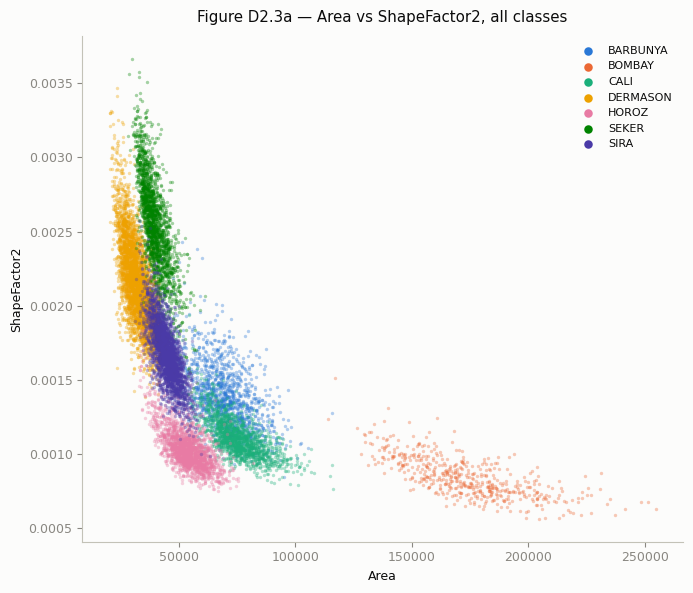

In [27]:
# Fig D2.3a Combined scatter, all 7 classes at once (quick overview)

fig, ax = plt.subplots(figsize=(7, 6))
for c in CLASS_ORDER:
    subset = df[df['Class'] == c]
    ax.scatter(subset[var1], subset[var2], s=6, alpha=0.35, linewidths=0,
               color=CLASS_COLORS[c], label=c)
ax.set_xlabel(var1)
ax.set_ylabel(var2)
ax.set_title(f"Figure D2.3a — {var1} vs {var2}, all classes")
leg = ax.legend(frameon=False, markerscale=2.5, loc='best', fontsize=8)
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
savefig("figD2_3a_separability_scatter_combined.png")
plt.show()


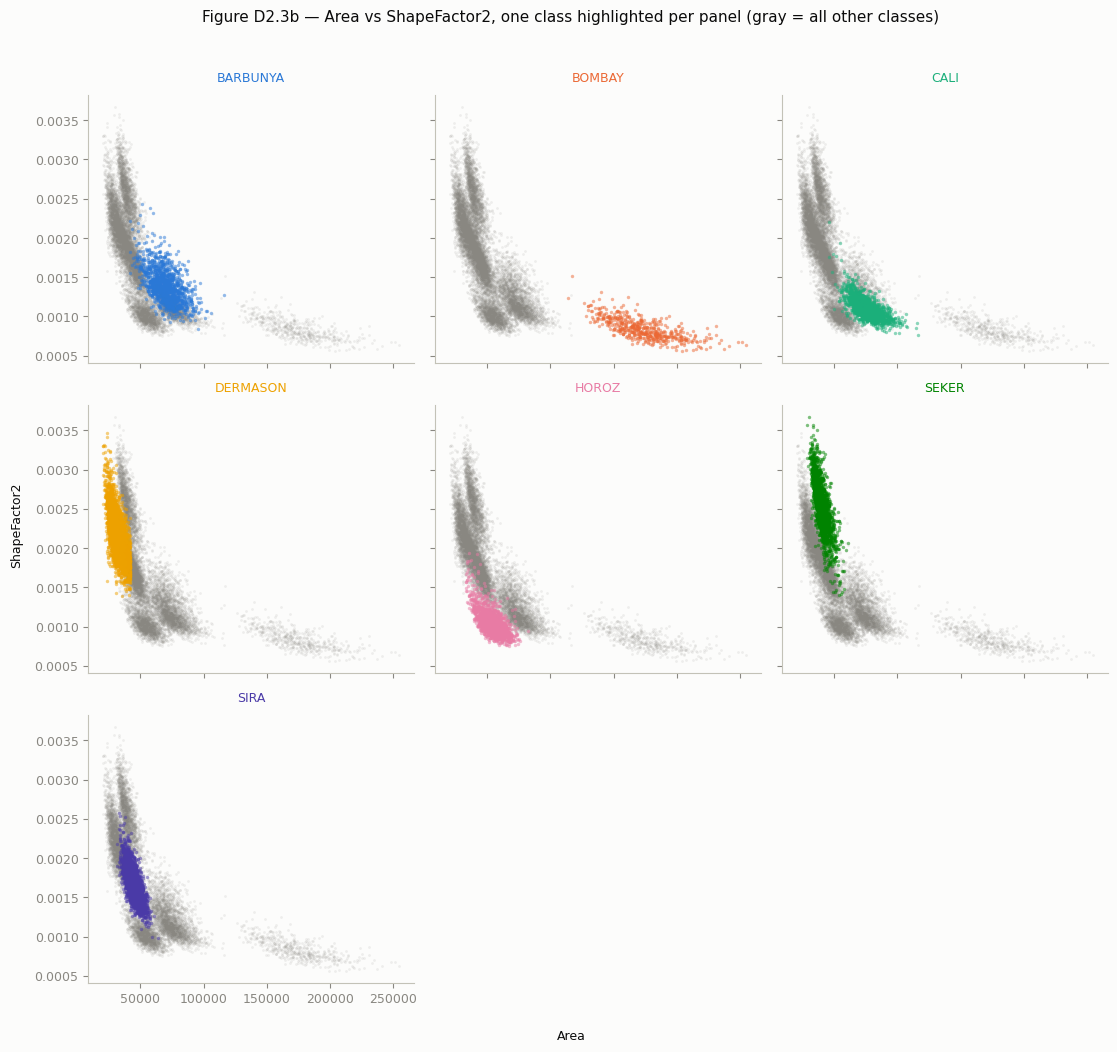

In [28]:
# Fig D2.3b -- Same 2 variables, small multiples (one class highlighted each)

n_classes = len(CLASS_ORDER)
grid_cols = 3
grid_rows = int(np.ceil(n_classes / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(11, 3.3 * grid_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(CLASS_ORDER):
    ax = axes[i]
    background = df[df['Class'] != c]
    highlight = df[df['Class'] == c]
    ax.scatter(background[var1], background[var2], s=4, alpha=0.12,
               color=TEXT_MUTED, linewidths=0)
    ax.scatter(highlight[var1], highlight[var2], s=6, alpha=0.5, linewidths=0,
               color=CLASS_COLORS[c])
    ax.set_title(c, fontsize=9, color=CLASS_COLORS[c])
for j in range(n_classes, len(axes)):
    axes[j].axis('off')
fig.suptitle(f"Figure D2.3b — {var1} vs {var2}, one class highlighted per panel "
             f"(gray = all other classes)", y=1.02, fontsize=11)
fig.text(0.5, -0.02, var1, ha='center', fontsize=9)
fig.text(-0.01, 0.5, var2, va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
savefig("figD2_3b_separability_scatter_small_multiples.png")
plt.show()


In [31]:
# Univariate EDA summary / working notes for the group

print("=" * 70)
print("DAY 2 UNIVARIATE EDA SUMMARY -- Dry Bean Dataset")
print("=" * 70)
print(f"Features examined: {n_features}")
print(f"Classes: {CLASS_ORDER}")
print(f"Most right/left-skewed feature: {skew_summary.index[0]} (skew={skew_summary.iloc[0]:.2f})")
print(f"Features with |skew| > 1: {len(highly_skewed)}")
print(f"Most separating single feature: {sep_series.index[0]} (ratio={sep_series.iloc[0]:.3f})")
print(f"Least separating single feature: {sep_series.index[-1]} (ratio={sep_series.iloc[-1]:.3f})")
print(f"2-variable separability view: {var1} x {var2} (Figures D2.3a/b)")


DAY 2 UNIVARIATE EDA SUMMARY -- Dry Bean Dataset
Features examined: 16
Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Most right/left-skewed feature: Area (skew=2.95)
Features with |skew| > 1: 9
Most separating single feature: Area (ratio=12.798)
Least separating single feature: Extent (ratio=0.186)
2-variable separability view: Area x ShapeFactor2 (Figures D2.3a/b)


# Dry Bean EDA: Key Insights

## BOMBAY separates almost by itself

Area is the single strongest separating feature (ratio 12.80, more than 2x the runner-up). BOMBAY's mean Area (173,485) is over double the next-largest class (CALI, 75,538) and nearly 5x the smallest (DERMASON, 32,119). The same holds for Perimeter, ConvexArea, EquivDiameter, and both axis lengths. In the Figure D2.3a scatter, BOMBAY forms a visually isolated cluster with almost no overlap. This class needs no clever feature engineering to detect, just size.

## SEKER and HOROZ are the shape extremes

Across every scale-invariant shape feature, SEKER and HOROZ sit at opposite ends: Eccentricity (SEKER 0.585 vs. HOROZ 0.867), AspectRation (SEKER 1.245 vs. HOROZ 2.026), Compactness (SEKER 0.897 vs. HOROZ 0.701), roundness (SEKER 0.945 vs. HOROZ 0.794), ShapeFactor3 (SEKER 0.805 vs. HOROZ 0.492). This lines up with the bean names: HOROZ ("rooster bean") is the most elongated variety, SEKER ("sugar bean") the most round, the shape features are measuring exactly what the earlier reference photos suggested.

## The middle 5 classes overlap heavily on size and shape alone

Excluding BOMBAY, BARBUNYA, CALI, DERMASON, SEKER, and SIRA span overlapping Area ranges (roughly 32k–76k) and overlapping AspectRation/Compactness bands. SIRA in particular sits in the middle of nearly every feature's distribution,  it's the hardest single class to isolate with any one or two variables. Extent is the weakest single separator of all 16 features (ratio 0.186); all seven classes cluster tightly between 0.71–0.78 on it.

## Area x ShapeFactor2 (Figure D2.3a/b): confirms the pattern, doesn't fully resolve it

The automatic 2-variable pick (top-ranked Area + next-best non-redundant ShapeFactor2, r = -0.639) visually confirms both findings above: BOMBAY splits off completely, and SEKER/DERMASON separate from HOROZ along the ShapeFactor2 axis even where their Area ranges overlap. But BARBUNYA, CALI, and SIRA still overlap substantially in this 2D view, full 7-class separation will need more than two features, which is expected and simply confirms the value of a multivariate model over any 2D projection.

## Skewness (9 of 16 features, |skew| > 1) has an identifiable cause, not just noise

All the positively-skewed features (Area, ConvexArea, MinorAxisLength, EquivDiameter, Perimeter, MajorAxisLength, skew 1.36 to 2.95) are size measurements, and the skew is very likely driven by BOMBAY sitting far out on the right tail as its own distinct subpopulation, not by noisy within-class distributions. The negatively-skewed features (ShapeFactor4, Solidity, Eccentricity) are bounded ratios pulled left mainly by SEKER's much lower Eccentricity (mean 0.585, min 0.219) relative to the other six classes.

## What this means for Data Preparation

- A log or Box-Cox transform on the skewed size features should be evaluated per-model (helps Logistic Regression, unnecessary for tree-based models), but note the skew is class-structure, not univariate noise, transforming won't "fix" BOMBAY's separation, it's already trivially separable.
- Shape features (AspectRation, Eccentricity, Compactness, roundness, ShapeFactor3) carry real, non-redundant discriminative power beyond size and should not be dropped even after addressing size-feature multicollinearity (Day 2 audit finding), they're what separates SEKER from HOROZ and could help pull SIRA/BARBUNYA/CALI apart.
- No 2-variable view fully separates all 7 classes, which is expected and simply reinforces that Modeling (not manual 2D feature selection) is where the harder classes will actually get resolved, useful context to include in Data Understanding when justifying the modeling approach.


In [32]:
# DATA PREPARATION

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# TODO: replace with whatever seed the team actually agreed on at kickoff

RANDOM_SEED = 42

ALL_16_FEATURES = df.columns.difference(['Class']).tolist()
print("Starting from raw df:", df.shape)

Starting from raw df: (13611, 17)


In [33]:
# 4.1 Remove exact duplicate rows (flagged in the Day 2 audit)

n_before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
n_after = len(df_clean)
print(f"Dropped {n_before - n_after} duplicate rows ({n_before} -> {n_after})")

Dropped 68 duplicate rows (13611 -> 13543)


In [34]:
# 4.2 Missing / invalid values

missing = df_clean[ALL_16_FEATURES].isnull().sum()
print("Missing values in df_clean:\n", missing[missing > 0] if missing.any() else "None found.")

Missing values in df_clean:
 None found.


In [35]:
# 4.3 Categorical variable treatment
# Not applicable: every one of the 16 original features is a continuous
# geometric measurement (see Day 2 audit, section 2.7 -- no categorical
# predictors, no identifier columns in this dataset). No encoding step is
# needed on the feature side.

In [36]:
# 4.4 Target encoding

label_encoder = LabelEncoder()
df_clean['Class_encoded'] = label_encoder.fit_transform(df_clean['Class'])

print("Class label encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")

Class label encoding:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA


In [37]:
# 4.5 Train/test split -- BEFORE feature selection, so VIF never sees test rows

X_full = df_clean[ALL_16_FEATURES]
y = df_clean['Class']                          # string labels -- human-readable output
y_encoded = df_clean['Class_encoded']          # integer labels -- for libraries that require them (e.g. XGBoost)

X_train_full, X_test_full, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X_full, y, y_encoded, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print("Train shape (all 16 features):", X_train_full.shape, "| Test shape:", X_test_full.shape)

Train shape (all 16 features): (10834, 16) | Test shape: (2709, 16)


In [38]:
# 4.6 Multicollinearity: iterative VIF-based feature selection

VIF_THRESHOLD = 10.0

def compute_vif(X):
    """VIF for every column in X, against all the OTHER columns in X.
    Near-perfectly collinear columns (e.g. Area vs. ConvexArea, r~1.0) make
    the design matrix singular/poorly conditioned -- statsmodels warns about
    this but still returns a valid (very large, effectively infinite) VIF,
    which is exactly the correct signal to eliminate that column next, so
    the expected warning is suppressed here rather than silencing anything
    that changes the result."""
    X_with_const = sm.add_constant(X)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        vifs = pd.Series(
            [variance_inflation_factor(X_with_const.values, i)
             for i in range(1, X_with_const.shape[1])],
            index=X.columns,
        )
    return vifs.sort_values(ascending=False)


print("VIF for all 16 features (X_train_full), before any removal:")
print(compute_vif(X_train_full).round(2))

X_vif_working = X_train_full.copy()
elimination_log = []
while True:
    vifs = compute_vif(X_vif_working)
    worst_feature, worst_vif = vifs.index[0], vifs.iloc[0]
    if worst_vif <= VIF_THRESHOLD or X_vif_working.shape[1] <= 1:
        break
    elimination_log.append((worst_feature, worst_vif))
    X_vif_working = X_vif_working.drop(columns=[worst_feature])

FEATURE_COLS = X_vif_working.columns.tolist()

print(f"\nIterative elimination log (threshold VIF > {VIF_THRESHOLD}):")
for feature, vif in elimination_log:
    print(f"  Dropped {feature:<20s} (VIF = {vif:,.2f} at time of removal)")
print(f"\nDropped {len(elimination_log)} feature(s): {[f for f, _ in elimination_log]}")
print(f"Retained {len(FEATURE_COLS)} predictors: {FEATURE_COLS}")
print("\nFinal VIF for retained features (all should now be <= threshold):")
print(compute_vif(X_vif_working).round(2))

VIF for all 16 features (X_train_full), before any removal:
EquivDiameter      312244.60
Compactness        270180.86
ShapeFactor3       195723.97
MajorAxisLength     87007.78
Area                85873.52
ConvexArea          83475.78
MinorAxisLength     76592.43
AspectRation        13518.12
Perimeter            3834.85
ShapeFactor2         1232.68
Eccentricity         1154.45
ShapeFactor1          605.94
roundness             108.68
ShapeFactor4           65.88
Solidity               14.41
Extent                  1.23
dtype: float64

Iterative elimination log (threshold VIF > 10.0):
  Dropped EquivDiameter        (VIF = 312,244.60 at time of removal)
  Dropped Compactness          (VIF = 265,714.05 at time of removal)
  Dropped Area                 (VIF = 57,561.26 at time of removal)
  Dropped MajorAxisLength      (VIF = 4,443.06 at time of removal)
  Dropped Perimeter            (VIF = 1,929.91 at time of removal)
  Dropped ShapeFactor3         (VIF = 1,169.82 at time of removal)
  D

In [39]:
# 4.7 Apply the VIF-selected feature list everywhere
X_train = X_train_full[FEATURE_COLS]
X_test = X_test_full[FEATURE_COLS]

df_model = df_clean[FEATURE_COLS + ['Class', 'Class_encoded']].copy()
print("Cleaned/transformed dataset shape (VIF-selected features + target):", df_model.shape)

Cleaned/transformed dataset shape (VIF-selected features + target): (13543, 9)


In [47]:
df_model.head()


,ConvexArea,Eccentricity,Extent,ShapeFactor1,ShapeFactor4,Solidity,roundness,Class,Class_encoded
0,28715,0.549812,0.763923,0.007332,0.998724,0.988856,0.958027,SEKER,5
1,29172,0.411785,0.783968,0.006979,0.998430,0.984986,0.887034,SEKER,5
2,29690,0.562727,0.778113,0.007244,0.999066,0.989559,0.947849,SEKER,5
3,30724,0.498616,0.782681,0.007017,0.994199,0.976696,0.903936,SEKER,5
4,30417,0.333680,0.773098,0.006697,0.999166,0.990893,0.984877,SEKER,5


In [40]:
# 4.8 Save the cleaned and transformed dataset (Deliverable #3)

CLEANED_CSV_PATH = '/content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Cleaned.csv'
df_model.to_csv(CLEANED_CSV_PATH, index=False)
print(f"Saved cleaned/transformed dataset ({df_model.shape[0]} rows x {df_model.shape[1]} cols) to:\n  {CLEANED_CSV_PATH}")

Saved cleaned/transformed dataset (13543 rows x 9 cols) to:
  /content/drive/MyDrive/DAMO510 Final Project/DAMO510_FinalProject_TeamJMV_Dataset_Cleaned.csv


In [41]:
# 4.9 Scaling decisions (MODEL-DEPENDENT preprocessing)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

print("StandardScaler mean_ (from X_train only):\n", pd.Series(scaler.mean_, index=FEATURE_COLS).round(3))
print("\nUsage going forward:")
print("  Logistic Regression        -> X_train_scaled / X_test_scaled")
print("  Random Forest, XGBoost     -> X_train / X_test (raw, unscaled)")

StandardScaler mean_ (from X_train only):
 ConvexArea      53736.120
Eccentricity        0.750
Extent              0.750
ShapeFactor1        0.007
ShapeFactor4        0.995
Solidity            0.987
roundness           0.874
dtype: float64

Usage going forward:
  Logistic Regression        -> X_train_scaled / X_test_scaled
  Random Forest, XGBoost     -> X_train / X_test (raw, unscaled)


In [49]:
# 4.10 Class imbalance, staged, not yet intervened on

print("Class balance preserved by the stratified split:")
print("  y_train:\n", (y_train.value_counts(normalize=True) * 100).round(2))
print("  y_test:\n", (y_test.value_counts(normalize=True) * 100).round(2))


Class balance preserved by the stratified split:
  y_train:
 Class
DERMASON    26.19
SIRA        19.47
SEKER       14.96
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.86
Name: proportion, dtype: float64
  y_test:
 Class
DERMASON    26.17
SIRA        19.45
SEKER       14.99
HOROZ       13.73
CALI        12.03
BARBUNYA     9.78
BOMBAY       3.84
Name: proportion, dtype: float64
